<a href="https://colab.research.google.com/github/Ameenota/HF-LLM/blob/main/Simplified_RAG_DataProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Small Business Chatbot**

RAG (Retrieval Augmented Generation) allows us to feed custom data into a language model. This has a large number of applications (customer support chatbot). Below we will build a RAG based chatbot for a family owned printing business. The business has around 200 of articles on their site. We will use this text to "augment" our chatbot and deploy a fulling working demo.

To run this you need to get your token from HuggingFace and create a secrect called HF_TOKEN with it.

Part 1 of this is Scraping Data which is covered [in another notebook](https://colab.research.google.com/drive/1rwjVCvog0BC97mVqQJ4q27T3kOnryOsX?usp=sharing). Below we will process the RAW data and prepare it for use in RAG

In [1]:
%%capture
# first we take care of setup and our globals
!pip install faiss-cpu langchain-text-splitters -q

from google.colab import userdata
HF_TOKEN=userdata.get('HF_TOKEN')

EMBEDDING_MODEL_NAME = "BAAI/bge-small-en-v1.5"
RAW_REPO_ID = "sagsan/orchid-website-data" ## contains just what we downloaded from the website
PROCESSED_REPO_ID = "sagsan/orchid-website-data-processed"


## Data processing
Our RAW dataset exists in HF, we will download it process it and upload to another set. This includes the following steps
1) Examine the data and remove any obvious noise.
2) Chunk the large text so it fits in our models window
3) Create Embeddings and store everything in a HF dataset.

The reason we push everything into an HF dataset is that we don't need to crawl the website regularly or create embeddings (which can be slow). We can simply download preprocessed data which will be significantly faster.

Below I added a "length" within the dataset. I also did a histogram of length. Looking at the plot it is obvious that there are a large number of documents that are between 0->1000 length. Most of these are just noise and will not be useful in our search. We will remove them later.

In [2]:
# First download our dataset and convert it to pandas as thats makes the modifications easy.
from datasets import load_dataset

dataset = load_dataset(RAW_REPO_ID ,split="train", token=HF_TOKEN)
df = dataset.to_pandas()
df.head()


,source,title,text,date_crawled,length,doc,embeddings
0,https://orchiddigitals.com,Orchid Digitals - Pune's Premier Prints Provid...,## WHAT ARE YOU LOOKING FOR TODAY?\n**Road Dir...,None,3305,TITLE: Orchid Digitals - Pune's Premier Prints...,"[-0.025262447, -0.034829445, 0.023602769, 0.00..."
1,https://orchiddigitals.com,Orchid Digitals - Pune's Premier Prints Provid...,## WHAT ARE YOU LOOKING FOR TODAY?\n**Road Dir...,None,3305,TITLE: Orchid Digitals - Pune's Premier Prints...,"[-0.025262447, -0.034829445, 0.023602769, 0.00..."
2,https://orchiddigitals.com/advertising-brandin...,"In-store Branding Campaign. Prints, Installati...",* Pet shops across Pune are branded with produ...,None,905,"TITLE: In-store Branding Campaign. Prints, Ins...","[-0.0028934835, -0.028128408, -0.0035337838, -..."
3,https://orchiddigitals.com/blog,Our Blogs - Orchid Digitals,## What do you feel like exploring?\n * I wan...,None,343,TITLE: Our Blogs - Orchid Digitals\nSOURCE: ht...,"[-0.049601067, -0.02999353, 0.029179847, 0.027..."
4,https://orchiddigitals.com/contact-us,"Contact details, address, email ids and phone ...",Orchid Digitals is situated right in Pune’s ci...,None,1057,"TITLE: Contact details, address, email ids and...","[0.012001651, -0.05541443, -0.03572841, -0.009..."


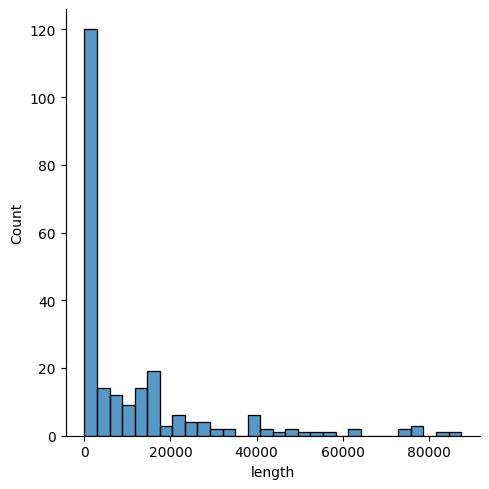

In [3]:
from datasets import Dataset
from huggingface_hub import login, HfApi
import os
import pandas as pd
import seaborn as sns

def process_data(rag_df):
  #create length field
  df["length"] = df["text"].str.len()
  sns.displot(df["length"],bins=30)

  #create a combined text doc
  df["doc"] = (
      "TITLE: " + df['title'] +
      "\nSOURCE: " + df['source'] +
      "\nCONTENT: " + df['text']
  )
  return df


df = process_data(df)


In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def get_chunked_data(_df):
  # 2. Initialize the Text Splitter
  # RecursiveCharacterTextSplitter is generally the best choice for RAG as it tries
  # to split by paragraph, then sentence, then word, preserving meaning hierarchy.
  splitter = RecursiveCharacterTextSplitter(
      # Chunk size controls the maximum length of a chunk (in characters).
      chunk_size=1000,
      # Chunk overlap ensures context carries over between chunks.
      chunk_overlap=100,
      separators=["\n\n", "\n", " ", ""],
      length_function=len,
      is_separator_regex=False,
  )

  _df['chunks'] = _df['doc'].apply(lambda x: splitter.split_text(x))
  _df = _df.explode('chunks', ignore_index=True)
  _df['chunk_index'] = _df.groupby('source').cumcount()

  return _df
df_chunked = get_chunked_data(df)
df = df_chunked



In [5]:
df.describe(include="object")

,source,title,text,date_crawled,doc,embeddings,chunks
count,3429,3429,3429,0,3429,3429,3429
unique,231,143,130,0,231,232,3170
top,https://orchiddigitals.com/inkjet-printed-cust...,"What is the Difference in Solvent, Eco-Solvent...","## What is the Difference Between Solvent, Eco...",NaN,TITLE: Self Adhesive Vinyl Banners Printed at ...,"[-0.031028867, 0.014736042, -0.0008112658, -0....",## [What is lamination in the printing industr...
freq,109,200,200,NaN,109,109,4


Below we create the vector embeddings using "BAAI/bge-small-en-v1.5" as our model. This is a very small model (33 million params) purpose built for RAG.

In [6]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = SentenceTransformer(EMBEDDING_MODEL_NAME)

In [ ]:

def create_embeddings_and_upload(df):
  dataset = Dataset.from_pandas(df)

  # Function to compute embeddings for a batch of texts
  def compute_embeddings(batch):
      return {'embeddings': EMBEDDING_MODEL.encode(batch["chunks"], convert_to_numpy=True)}

  # Add the 'embeddings' column to the dataset
  dataset_with_embeddings = dataset.map(
      compute_embeddings,
      batched=True,
      desc="Creating Embeddings"
  )
  print("Embeddings created.")
  dataset_with_embeddings.push_to_hub(PROCESSED_REPO_ID, private=True) # uncomment this if you actually want to push to hub

create_embeddings_and_upload(df)


Creating Embeddings:   0%|          | 0/3429 [00:00<?, ? examples/s]

### Download the Data and Process for startup

Load the dataseet and add FAISS embeddings.

In [2]:
from datasets import load_dataset
def prepare_data_for_rag():
  dataset = load_dataset(REPO_ID ,split="train", token=HF_TOKEN)
  dataset.filter(lambda x: x["length"] > 1000)

  # Add the FAISS index to the dataset
  dataset.add_faiss_index(column='embeddings')
  print("FAISS index built successfully.")
  return dataset

DATASET = prepare_data_for_rag()
DATASET

NameError: name 'REPO_ID' is not defined

In [ ]:
len(DATASET[33]['embeddings'])

384

3377